# Análise Exploratória de Dados

- Conjunto de Dados [`Bank Customer Churn Prediction Dataset`](https://www.kaggle.com/datasets/saurabhbadole/bank-customer-churn-prediction-dataset)
- **Objetivo:** Identificar padrões e fatores associados ao churn (cancelamento) de clientes bancários.
- **Variável-alvo:** `Exited` — 1 se o cliente encerrou a conta (churned), 0 caso contrário.

## Setup

In [56]:
# @title Carregando Bibliotecas
import os

import kagglehub
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from matplotlib import pyplot as plt
from scipy import stats


In [83]:
# @title Download de dados
path = kagglehub.dataset_download("saurabhbadole/bank-customer-churn-prediction-dataset")
print("Path to dataset files:", path)
print("Arquivos na pasta:", os.listdir(path))

Path to dataset files: C:\Users\jaime\.cache\kagglehub\datasets\saurabhbadole\bank-customer-churn-prediction-dataset\versions\2
Arquivos na pasta: ['Churn_Modelling.csv']


In [58]:
# @title Importando conjunto de dados
df = pd.read_csv(os.path.join(path, "Churn_Modelling.csv"))

In [59]:
# Definindo tema do seaborn
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"


## Exploração Inicial dos Dados

In [60]:
display(Markdown("### Primeiras linhas"))
df.head()

### Primeiras linhas

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [61]:
display(Markdown("### Últimas linhas"))
df.tail()

### Últimas linhas

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1
9999,10000,15628319,Walker,792,France,Female,28,4,130142.79,1,1,0,38190.78,0


In [62]:
display(Markdown("### Informações das variáveis"))
df.info()

### Informações das variáveis

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB


A base possui 10.000 clientes e 14 colunas brutas. Como o objetivo é explicar churn, a exploração passa a usar `Exited` como eixo central: primeiro validamos qualidade dos dados, depois priorizamos variáveis com maior associação com a saída do cliente.


In [63]:
display(Markdown("### Resumo da Base"))

resumo_base = pd.DataFrame({
    "métrica": [
        "linhas",
        "colunas brutas",
        "clientes únicos",
        "duplicatas completas",
        "taxa de churn (%)"
    ],
    "valor": [
        len(df),
        df.shape[1],
        df["CustomerId"].nunique(),
        df.duplicated().sum(),
        round(df["Exited"].mean() * 100, 2)
    ]
})

display(resumo_base)


### Resumo da Base

,métrica,valor
0,linhas,10000.00
1,colunas brutas,14.00
2,clientes únicos,10000.00
3,duplicatas completas,0.00
4,taxa de churn (%),20.37


In [64]:
display(Markdown("### Cardinalidade e Tipos"))

perfil_colunas = (
    pd.DataFrame({
        "tipo_dado": df.dtypes.astype(str),
        "n_unicos": df.nunique(),
        "nulos": df.isna().sum(),
        "nulos_%": (df.isna().mean() * 100).round(2)
    })
    .sort_values(["nulos_%", "n_unicos"], ascending=[False, False])
)

display(perfil_colunas)


### Cardinalidade e Tipos

,tipo_dado,n_unicos,nulos,nulos_%
RowNumber,int64,10000,0,0.0
CustomerId,int64,10000,0,0.0
EstimatedSalary,float64,9999,0,0.0
Balance,float64,6382,0,0.0
Surname,str,2932,0,0.0
CreditScore,int64,460,0,0.0
Age,int64,70,0,0.0
Tenure,int64,11,0,0.0
NumOfProducts,int64,4,0,0.0
Geography,str,3,0,0.0


---

As colunas `RowNumber`, `CustomerId` e `Surname` são identificadores sem valor analítico para essa etapa então serão descartadas.

As variáveis `HasCrCard`, `IsActiveMember` e `Exited` são binárias (0/1) e serão convertidas para categoria com rótulos descritivos para facilitar a leitura dos gráficos.

---

In [65]:
# Remove colunas de identificação sem valor analítico
df = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])

# Converte variáveis binárias para categórico com rótulos legíveis
df['HasCrCard'] = df['HasCrCard'].map({1: 'Sim', 0: 'Não'}).astype('category')
df['IsActiveMember'] = df['IsActiveMember'].map({1: 'Ativo', 0: 'Inativo'}).astype('category')
df['Exited'] = df['Exited'].map({1: 'Churn', 0: 'Retido'}).astype('category')

df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,Sim,Ativo,101348.88,Churn
1,608,Spain,Female,41,1,83807.86,1,Não,Ativo,112542.58,Retido
2,502,France,Female,42,8,159660.80,3,Sim,Inativo,113931.57,Churn
3,699,France,Female,39,1,0.00,2,Não,Inativo,93826.63,Retido
4,850,Spain,Female,43,2,125510.82,1,Sim,Ativo,79084.10,Retido


## Dicionário de Dados

In [66]:
# @title Dicionário de dados
df_dict = pd.DataFrame([
    {"variavel": "CreditScore",      "descricao": "Score de crédito do cliente (300–850).",                          "tipo": "quantitativa", "subtipo": "discreta"},
    {"variavel": "Geography",        "descricao": "País de residência: France, Germany ou Spain.",                    "tipo": "qualitativa",  "subtipo": "nominal"},
    {"variavel": "Gender",           "descricao": "Gênero do cliente: Male ou Female.",                               "tipo": "qualitativa",  "subtipo": "nominal"},
    {"variavel": "Age",              "descricao": "Idade do cliente em anos.",                                         "tipo": "quantitativa", "subtipo": "discreta"},
    {"variavel": "Tenure",           "descricao": "Há quantos anos o cliente está no banco (0–10).",                   "tipo": "quantitativa", "subtipo": "discreta"},
    {"variavel": "Balance",          "descricao": "Saldo bancário atual do cliente.",                                  "tipo": "quantitativa", "subtipo": "contínua"},
    {"variavel": "NumOfProducts",    "descricao": "Número de produtos bancários que o cliente possui (1–4).",          "tipo": "quantitativa", "subtipo": "discreta"},
    {"variavel": "HasCrCard",        "descricao": "Indica se o cliente possui cartão de crédito (Sim/Não).",           "tipo": "qualitativa",  "subtipo": "nominal"},
    {"variavel": "IsActiveMember",   "descricao": "Indica se o cliente é membro ativo (Ativo/Inativo).",               "tipo": "qualitativa",  "subtipo": "nominal"},
    {"variavel": "EstimatedSalary",  "descricao": "Salário estimado anual do cliente.",                                "tipo": "quantitativa", "subtipo": "contínua"},
    {"variavel": "Exited",           "descricao": "Variável-alvo: Churn (encerrou conta) ou Retido.",                  "tipo": "qualitativa",  "subtipo": "nominal"},
])
display(df_dict)

,variavel,descricao,tipo,subtipo
0,CreditScore,Score de crédito do cliente (300–850).,quantitativa,discreta
1,Geography,"País de residência: France, Germany ou Spain.",qualitativa,nominal
2,Gender,Gênero do cliente: Male ou Female.,qualitativa,nominal
3,Age,Idade do cliente em anos.,quantitativa,discreta
4,Tenure,Há quantos anos o cliente está no banco (0–10).,quantitativa,discreta
5,Balance,Saldo bancário atual do cliente.,quantitativa,contínua
6,NumOfProducts,Número de produtos bancários que o cliente pos...,quantitativa,discreta
7,HasCrCard,Indica se o cliente possui cartão de crédito (...,qualitativa,nominal
8,IsActiveMember,Indica se o cliente é membro ativo (Ativo/Inat...,qualitativa,nominal
9,EstimatedSalary,Salário estimado anual do cliente.,quantitativa,contínua


## Tratamento de Valores Nulos

In [67]:
# @title Diagnóstico dos valores nulos
display(Markdown("#### Contagem de nulos por variável"))
print(df.isnull().sum())
print(f"\nTotal de nulos: {df.isnull().sum().sum()}")

#### Contagem de nulos por variável

CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Total de nulos: 0


O dataset não apresenta valores nulos então nenhum tratamento de imputação é necessário.

## Funções Auxiliares de EDA Direcionada

As funções abaixo evitam repetição e deixam a análise orientada ao alvo `Exited`. Para variáveis numéricas, a comparação usa Mann-Whitney U e tamanho de efeito rank-biserial. Para variáveis categóricas, a análise usa qui-quadrado, V de Cramér, taxa de churn e lift em relação à taxa média da base.


### Conceitos estatísticos usados nesta etapa

- **Correlação de Pearson** mede associação **linear** entre duas variáveis numéricas. Ela responde: quando uma variável aumenta, a outra tende a aumentar ou diminuir em linha reta? É útil quando a relação é aproximadamente linear e sem muitos outliers.
- **Correlação de Spearman** mede associação **monotônica**, isto é, se uma variável tende a subir enquanto a outra sobe ou desce, mesmo que a relação não seja uma linha reta. Como usa os rankings dos valores, é mais robusta para distribuições assimétricas e outliers.
- **Teste de Mann-Whitney U** compara duas distribuições independentes, como `Churn` vs. `Retido`, sem exigir normalidade. Ele ajuda a verificar se os valores de uma variável numérica tendem a ser maiores em um grupo do que no outro.
- **Tamanho de efeito rank-biserial (`r`)** complementa o p-valor. O p-valor indica se a diferença é estatisticamente detectável; o `r` indica se essa diferença é pequena, moderada ou grande na prática.
- **Qui-quadrado** avalia se duas variáveis categóricas estão associadas, por exemplo `Geography` e `Exited`.
- **V de Cramér** mede a força dessa associação categórica. Assim como o `r`, ajuda a diferenciar uma associação estatisticamente significativa de uma associação realmente relevante para a análise.

Em resumo: os testes indicam se há evidência estatística; os tamanhos de efeito indicam se o achado é importante o suficiente para orientar decisões de negócio ou modelagem.


In [68]:
# @title Funções auxiliares

CHURN_ORDER = ['Retido', 'Churn']
CHURN_PALETTE = {'Churn': '#d62728', 'Retido': '#1f77b4'}
BASE_CHURN_RATE = (df['Exited'] == 'Churn').mean() * 100


def mann_whitney_effect(data, group_col, value_col, group_a='Churn', group_b='Retido'):
    """Mann-Whitney U com tamanho de efeito rank-biserial r."""
    a = data.loc[data[group_col] == group_a, value_col].dropna()
    b = data.loc[data[group_col] == group_b, value_col].dropna()
    u_stat, p_value = stats.mannwhitneyu(a, b, alternative='two-sided')
    n_pairs = len(a) * len(b)
    r = 1 - (2 * u_stat) / n_pairs
    return pd.Series({
        'U': u_stat,
        'p': p_value,
        'r_abs': abs(round(r, 4)),
        'r_signed': round(r, 4),
        'mediana_churn': a.median(),
        'mediana_retido': b.median(),
        'delta_mediana': a.median() - b.median()
    })


def cramers_v(confusion_matrix):
    """V de Cramér corrigido para tabelas de contingência."""
    chi2 = stats.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.to_numpy().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2_corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    r_corr = r - ((r - 1) ** 2) / (n - 1)
    k_corr = k - ((k - 1) ** 2) / (n - 1)
    return np.sqrt(phi2_corr / min((k_corr - 1), (r_corr - 1)))


def churn_rate_por_grupo(data, group_col):
    """Taxa de churn, volume e lift por categoria."""
    out = (
        data.groupby(group_col, observed=True)
        .agg(
            clientes=('Exited', 'size'),
            churns=('Exited', lambda s: (s == 'Churn').sum()),
            churn_rate_pct=('Exited', lambda s: (s == 'Churn').mean() * 100)
        )
        .reset_index()
    )
    out['share_base_pct'] = out['clientes'] / len(data) * 100
    out['lift_vs_base'] = out['churn_rate_pct'] / BASE_CHURN_RATE
    return out.sort_values('churn_rate_pct', ascending=False)


def tabela_associacao_categorica(data, cols_cat):
    """Resume associação das variáveis categóricas com churn."""
    linhas = []
    for col in cols_cat:
        tab = pd.crosstab(data[col], data['Exited'])
        chi2, p_value, _, _ = stats.chi2_contingency(tab)
        taxas = churn_rate_por_grupo(data, col)
        maior_risco = taxas.iloc[0]
        menor_risco = taxas.iloc[-1]
        linhas.append({
            'variavel': col,
            'p': p_value,
            'cramers_v': cramers_v(tab),
            'categoria_maior_risco': maior_risco[col],
            'churn_maior_risco_%': maior_risco['churn_rate_pct'],
            'categoria_menor_risco': menor_risco[col],
            'churn_menor_risco_%': menor_risco['churn_rate_pct'],
            'lift_maior_risco': maior_risco['lift_vs_base']
        })
    return pd.DataFrame(linhas).sort_values('cramers_v', ascending=False)


def plot_churn_rate(data, group_col, ax=None, order=None, title=None, ylim=None):
    """Barplot padronizado de taxa de churn por grupo."""
    plot_data = churn_rate_por_grupo(data, group_col)
    if order is not None:
        plot_data = plot_data.set_index(group_col).reindex(order).reset_index()
    if ax is None:
        _, ax = plt.subplots(figsize=(8, 4))
    sns.barplot(data=plot_data, x=group_col, y='churn_rate_pct', color='#4c78a8', ax=ax)
    ax.axhline(BASE_CHURN_RATE, color='#444444', linestyle='--', linewidth=1, label=f'Média: {BASE_CHURN_RATE:.1f}%')
    for bar in ax.patches:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, height + 0.5, f'{height:.1f}%', ha='center', va='bottom', fontsize=9)
    ax.set_title(title or f'Taxa de Churn por {group_col}')
    ax.set_xlabel('')
    ax.set_ylabel('Churn (%)')
    if ylim:
        ax.set_ylim(*ylim)
    ax.legend(loc='upper right', frameon=True)
    return ax


## Perguntas e Hipóteses

> Cada pergunta recebeu um código (**Q1–Q8**) citado nos títulos dos gráficos e nas conclusões para rastreabilidade analítica.

| # | Pergunta | Hipótese |
|---|----------|----------|
| Q1 | Clientes mais velhos têm maior propensão ao churn? | Sim — clientes mais velhos podem ter necessidades financeiras diferentes e maior sensibilidade à experiência de atendimento. |
| Q2 | A localização geográfica influencia a taxa de churn? | Sim — clientes na Alemanha podem ter perfil e contexto competitivo distintos. |
| Q3 | Clientes com saldo bancário positivo apresentam maior churn? | Parcialmente — a presença de saldo pode ser mais importante que o valor absoluto do saldo. |
| Q4 | Membros ativos apresentam menor taxa de churn? | Sim — engajamento com o banco tende a criar retenção. |
| Q5 | O número de produtos contratados está associado ao churn? | Não-linear — 2 produtos pode indicar vínculo saudável; 3–4 produtos podem indicar fricção ou venda inadequada. |
| Q6 | Existe diferença na taxa de churn entre homens e mulheres? | Possivelmente — diferenças de perfil ou relacionamento podem aparecer no churn. |
| Q7 | O score de crédito difere entre clientes que fizeram churn e os que ficaram? | Pequena diferença — espera-se baixo poder discriminante isolado. |
| Q8 | Quais combinações de idade, produtos, saldo e país concentram maior risco? | Clientes mais velhos, com saldo positivo, 3–4 produtos e/ou Alemanha tendem a concentrar maior churn. |


## Análise Univariada

In [69]:
# @title Resumo Estatístico Orientado ao Churn

variaveis_quantitativas = df_dict.query("tipo == 'quantitativa'").variavel.tolist()
variaveis_qualitativas = [v for v in df_dict.query("tipo == 'qualitativa'").variavel.tolist() if v != 'Exited']

display(Markdown("#### Taxa base de churn"))
display(pd.DataFrame({'status': df['Exited'].value_counts().index, 'clientes': df['Exited'].value_counts().values, 'percentual': (df['Exited'].value_counts(normalize=True).values * 100).round(2)}))

display(Markdown("#### Variáveis quantitativas por status"))
resumo_quant_churn = (
    df.groupby('Exited', observed=True)[variaveis_quantitativas]
    .agg(['median', 'mean'])
    .T
    .round(2)
)
display(resumo_quant_churn)

display(Markdown("#### Variáveis categóricas: taxa de churn por grupo"))
for variavel in variaveis_qualitativas:
    display(Markdown(f"**{variavel}**"))
    display(churn_rate_por_grupo(df, variavel).round(2))


#### Taxa base de churn

,status,clientes,percentual
0,Retido,7963,79.63
1,Churn,2037,20.37


#### Variáveis quantitativas por status

Exited                      Churn    Retido
CreditScore     median     646.00    653.00
                mean       645.35    651.85
Age             median      45.00     36.00
                mean        44.84     37.41
Tenure          median       5.00      5.00
                mean         4.93      5.03
Balance         median  109349.29  92072.68
                mean     91108.54  72745.30
NumOfProducts   median       1.00      2.00
                mean         1.48      1.54
EstimatedSalary median  102460.84  99645.04
                mean    101465.68  99738.39

#### Variáveis categóricas: taxa de churn por grupo

...

,Gender,clientes,churns,churn_rate_pct,share_base_pct,lift_vs_base
0,Female,4543,1139,25.07,45.43,1.23
1,Male,5457,898,16.46,54.57,0.81


**HasCrCard**

,HasCrCard,clientes,churns,churn_rate_pct,share_base_pct,lift_vs_base
0,Não,2945,613,20.81,29.45,1.02
1,Sim,7055,1424,20.18,70.55,0.99


**IsActiveMember**

,IsActiveMember,clientes,churns,churn_rate_pct,share_base_pct,lift_vs_base
1,Inativo,4849,1302,26.85,48.49,1.32
0,Ativo,5151,735,14.27,51.51,0.70


### Distribuição de Variáveis Quantitativas

Base para as perguntas **Q1** (Age), **Q3** (Balance), **Q7** (CreditScore).

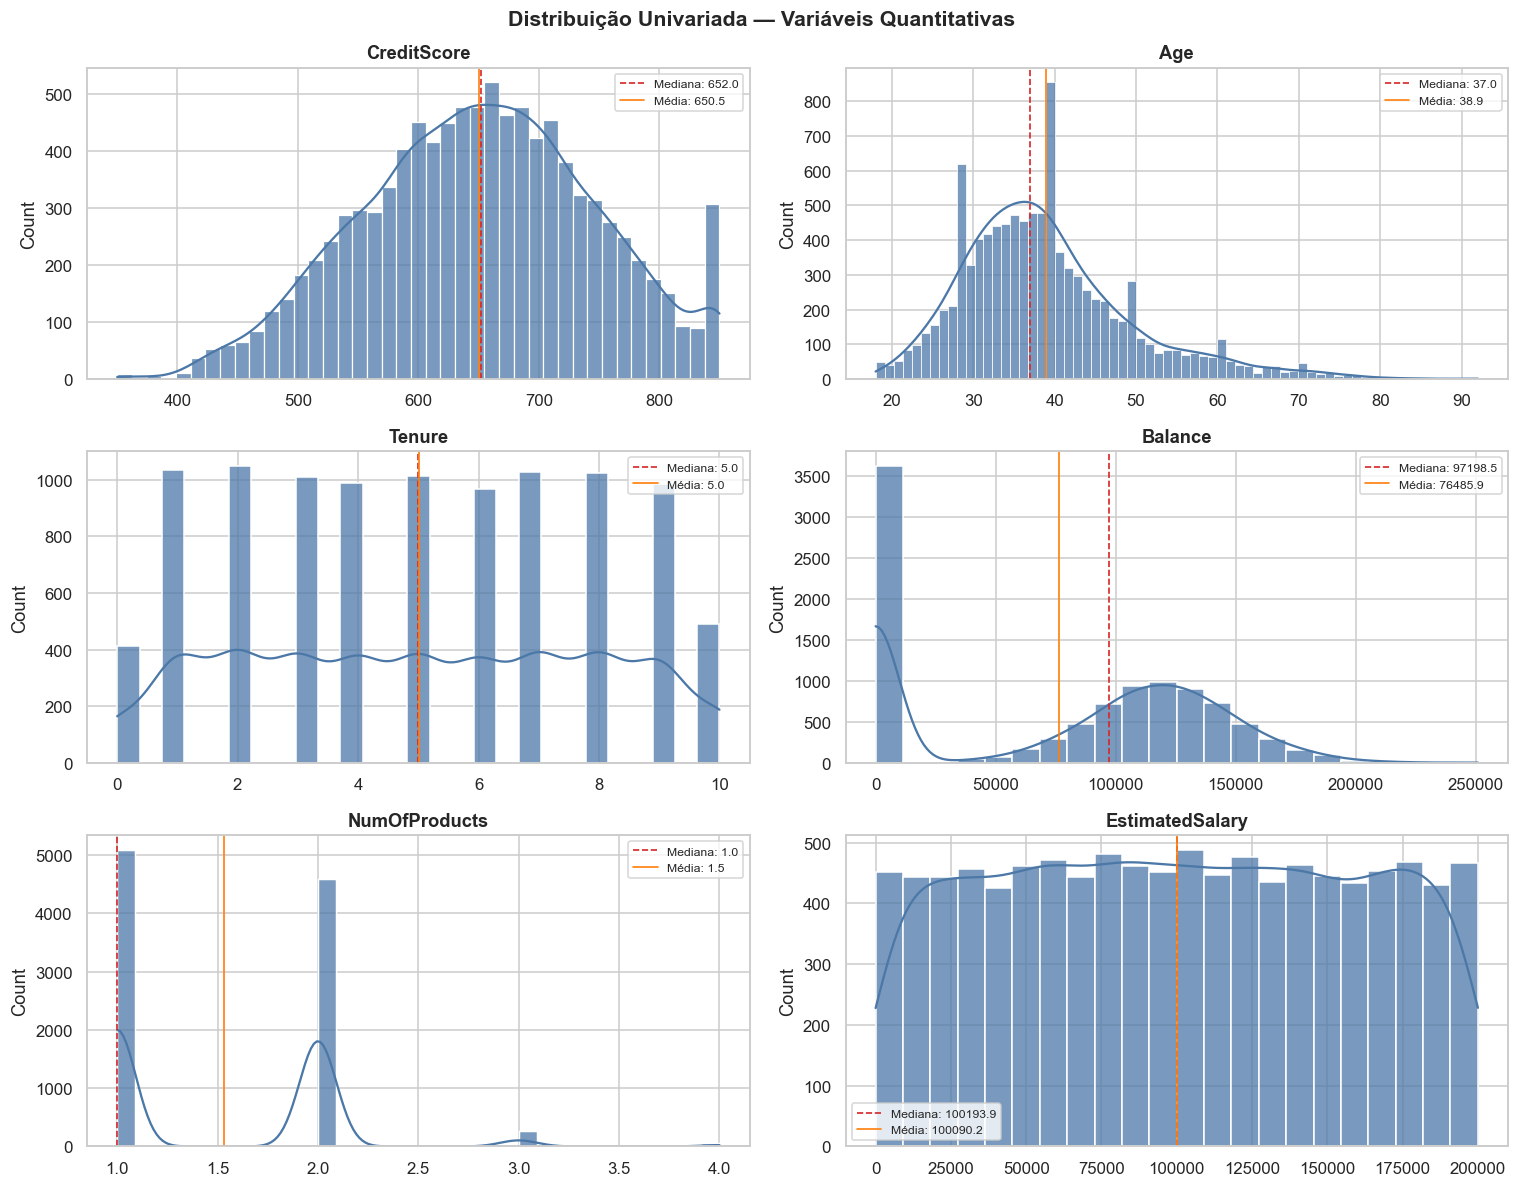

In [70]:
# @title Variáveis Quantitativas (univariada)

fig, axes = plt.subplots(3, 2, figsize=(14, 11))
axes = axes.flatten()

for ax, variavel in zip(axes, variaveis_quantitativas):
    sns.histplot(data=df, x=variavel, ax=ax, kde=True, alpha=0.75, color='#4c78a8')
    mediana = df[variavel].median()
    media = df[variavel].mean()
    ax.axvline(mediana, color='#d62728', linestyle='--', linewidth=1.1, label=f'Mediana: {mediana:.1f}')
    ax.axvline(media, color='#ff7f0e', linestyle='-', linewidth=1.1, label=f'Média: {media:.1f}')
    ax.set_title(variavel)
    ax.set_xlabel('')
    ax.legend(fontsize=8)

for ax in axes[len(variaveis_quantitativas):]:
    ax.set_visible(False)

fig.suptitle('Distribuição Univariada — Variáveis Quantitativas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


---

- **CreditScore**: distribuição aproximadamente simétrica, centrada em ~650.
- **Age**: ligeira assimetria positiva; maioria dos clientes entre 30–45 anos, com cauda à direita (clientes mais velhos).
- **Tenure**: distribuição quase uniforme entre 0 e 10 anos — o banco tem clientes de todas as «idades de relacionamento».
- **Balance**: bimodal — grande concentração de clientes com saldo zero (~3.600 casos) e uma distribuição aproximadamente normal para os demais (~100k–150k).
- **NumOfProducts**: majoritariamente 1 ou 2 produtos; poucos clientes com 3 ou 4.
- **EstimatedSalary**: distribuição uniforme entre 0 e 200k — o dataset foi gerado sinteticamente para simular diversidade salarial.

---

### Distribuição de Variáveis Qualitativas

Base para as perguntas **Q2** (Geography), **Q4** (IsActiveMember), **Q5** (NumOfProducts), **Q6** (Gender).

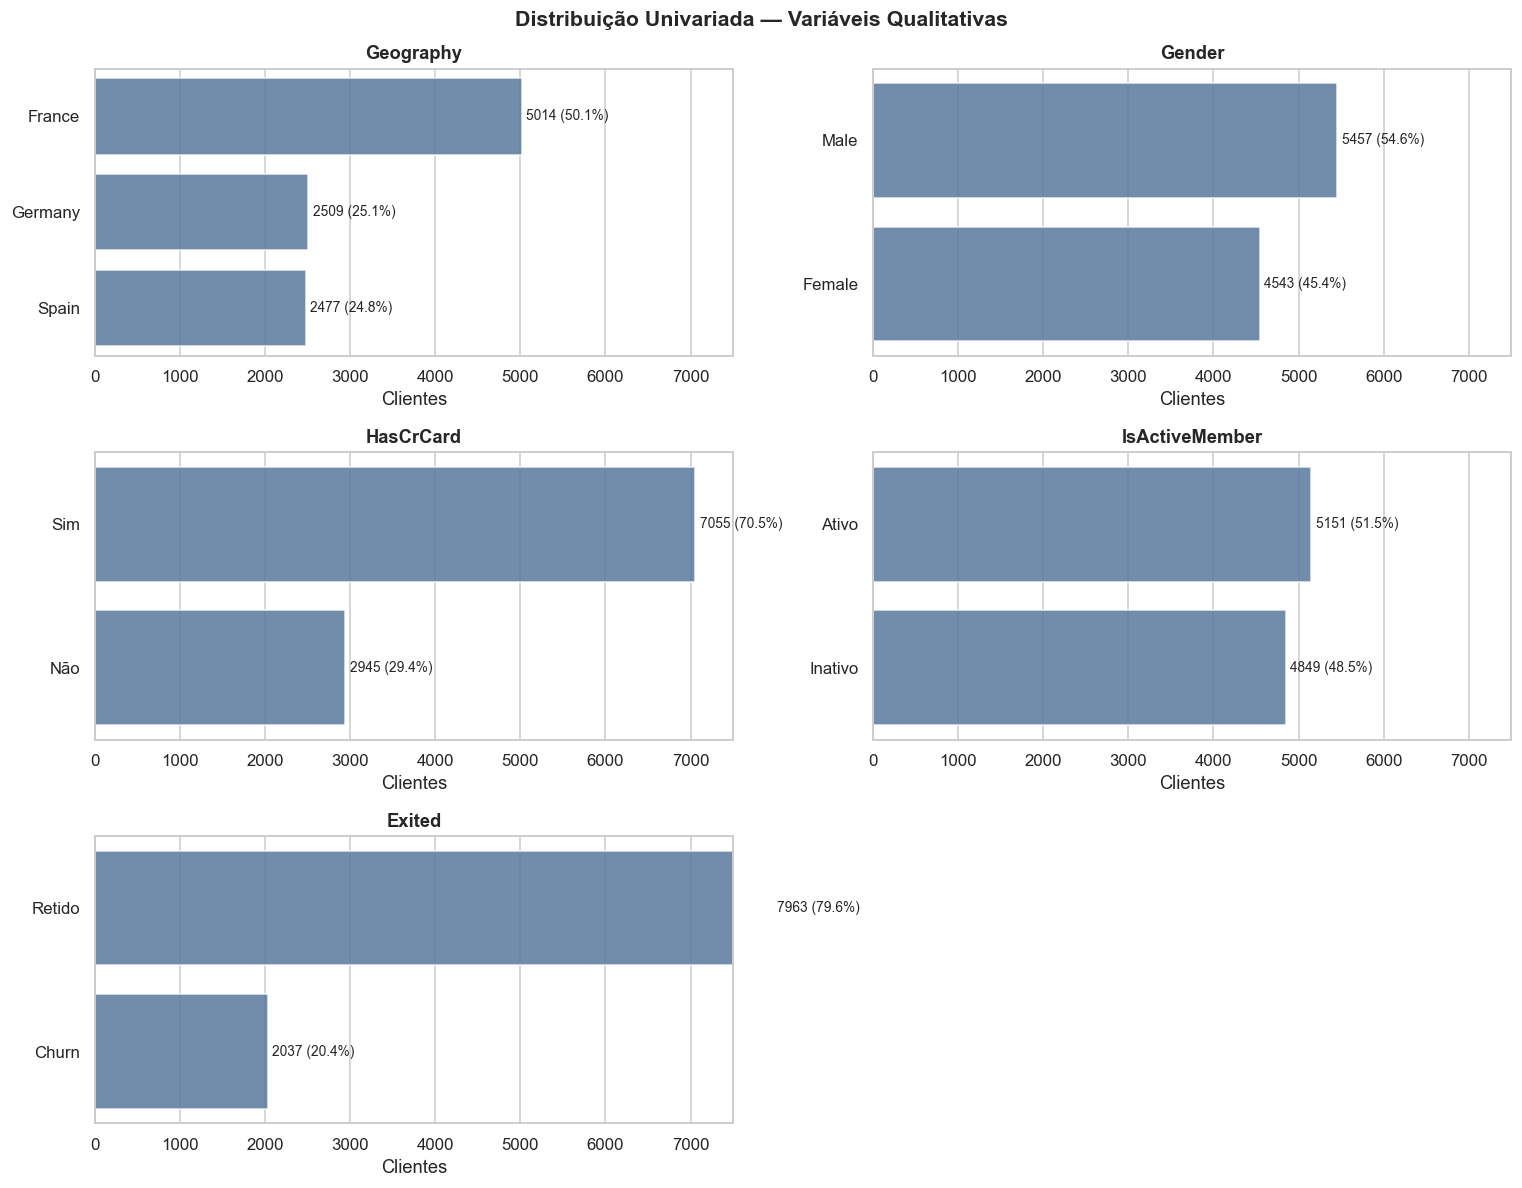

In [71]:
# @title Variáveis Qualitativas (univariada)

fig, axes = plt.subplots(3, 2, figsize=(14, 11))
axes = axes.flatten()

for ax, variavel in zip(axes, variaveis_qualitativas + ['Exited']):
    order = df[variavel].value_counts().index
    sns.countplot(data=df, y=variavel, ax=ax, order=order, color='#4c78a8', alpha=0.85)
    total = len(df)
    for bar in ax.patches:
        width = bar.get_width()
        ax.text(width + total * 0.005, bar.get_y() + bar.get_height() / 2, f'{width:.0f} ({width / total * 100:.1f}%)', va='center', fontsize=9)
    ax.set_title(variavel)
    ax.set_xlabel('Clientes')
    ax.set_ylabel('')
    ax.set_xlim(0, total * 0.75)

for ax in axes[len(variaveis_qualitativas) + 1:]:
    ax.set_visible(False)

fig.suptitle('Distribuição Univariada — Variáveis Qualitativas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


---

- **Geography**: França concentra ~50% dos clientes; Alemanha e Espanha dividem os outros 50%.
- **Gender**: leve predominância masculina (~54,6% vs. 45,4%).
- **HasCrCard**: maioria (~70%) possui cartão de crédito.
- **IsActiveMember**: clientes ativos e inativos estão em proporção próxima (~51%/49%).
- **Exited**: cerca de **20,4%** dos clientes fizeram churn — desbalanceamento moderado da variável-alvo.

---

## Análise Bivariada

### Relação entre Variáveis Quantitativas

#### Variáveis quantitativas ordenadas por tamanho de efeito

,variavel,U,p,r_abs,r_signed,mediana_churn,mediana_retido,delta_mediana
1,Age,11874649.5,0.0000,0.4641,-0.4641,45.00,36.00,9.00
4,NumOfProducts,6830625.5,0.0000,0.1578,0.1578,1.00,2.00,-1.00
3,Balance,9371186.5,0.0000,0.1555,-0.1555,109349.29,92072.68,17276.61
0,CreditScore,7839548.0,0.0199,0.0334,0.0334,646.00,653.00,-7.00
2,Tenure,7948575.5,0.1622,0.0199,0.0199,5.00,5.00,0.00
5,EstimatedSalary,8250768.0,0.2271,0.0173,-0.0173,102460.84,99645.04,2815.80


#### Variáveis categóricas ordenadas por V de Cramér

,variavel,p,cramers_v,categoria_maior_risco,churn_maior_risco_%,categoria_menor_risco,churn_menor_risco_%,lift_maior_risco
0,Geography,0.0000,0.1730,Germany,32.4432,France,16.1548,1.5927
3,IsActiveMember,0.0000,0.1556,Inativo,26.8509,Ativo,14.2691,1.3182
1,Gender,0.0000,0.1058,Female,25.0715,Male,16.4559,1.2308
2,HasCrCard,0.4924,0.0000,Não,20.8149,Sim,20.1843,1.0218


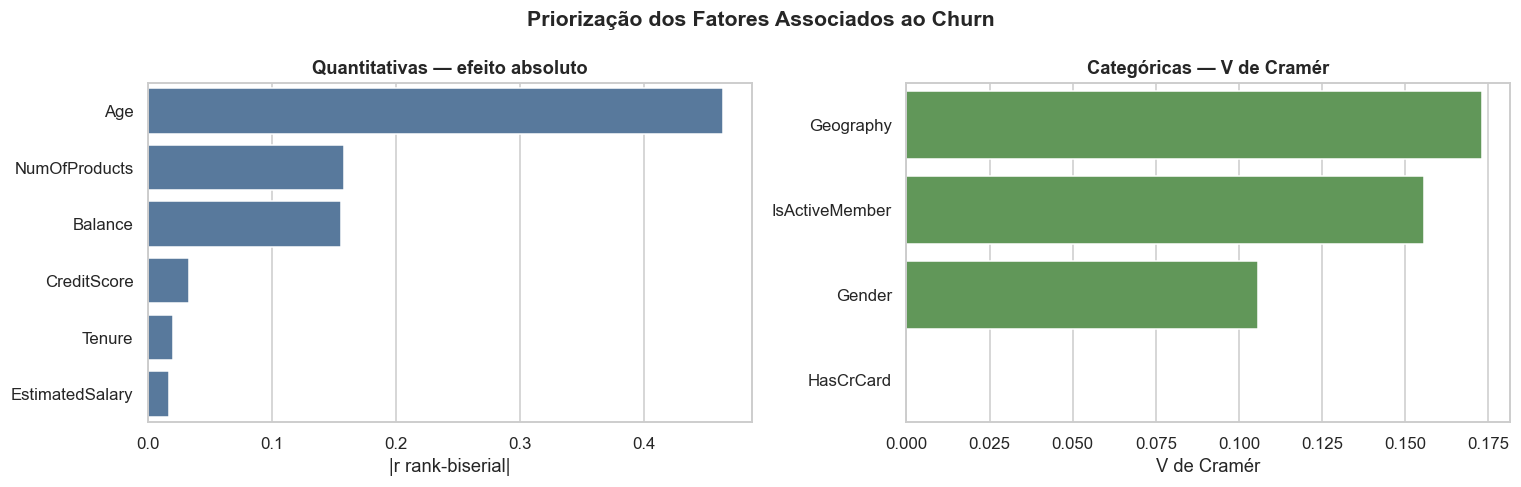

In [72]:
# @title Priorização bivariada — variáveis mais associadas ao churn

resumo_numerico = pd.DataFrame([
    {'variavel': col, **mann_whitney_effect(df, 'Exited', col).to_dict()}
    for col in variaveis_quantitativas
]).sort_values('r_abs', ascending=False)

resumo_categorico = tabela_associacao_categorica(df, variaveis_qualitativas)

display(Markdown('#### Variáveis quantitativas ordenadas por tamanho de efeito'))
display(resumo_numerico.round(4))

display(Markdown('#### Variáveis categóricas ordenadas por V de Cramér'))
display(resumo_categorico.round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.barplot(data=resumo_numerico, y='variavel', x='r_abs', ax=axes[0], color='#4c78a8')
axes[0].set_title('Quantitativas — efeito absoluto')
axes[0].set_xlabel('|r rank-biserial|')
axes[0].set_ylabel('')

sns.barplot(data=resumo_categorico, y='variavel', x='cramers_v', ax=axes[1], color='#59a14f')
axes[1].set_title('Categóricas — V de Cramér')
axes[1].set_xlabel('V de Cramér')
axes[1].set_ylabel('')

fig.suptitle('Priorização dos Fatores Associados ao Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


---

A priorização bivariada torna a EDA mais objetiva: antes de abrir análises detalhadas, ela mostra quais variáveis merecem mais atenção. `Age`, `NumOfProducts`, `IsActiveMember`, `Geography`, `Gender` e a presença de saldo concentram a maior parte do sinal exploratório. `CreditScore`, `Tenure`, `EstimatedSalary` e `HasCrCard` aparecem com associação fraca e devem ser tratados como variáveis secundárias.

---


### Correlação

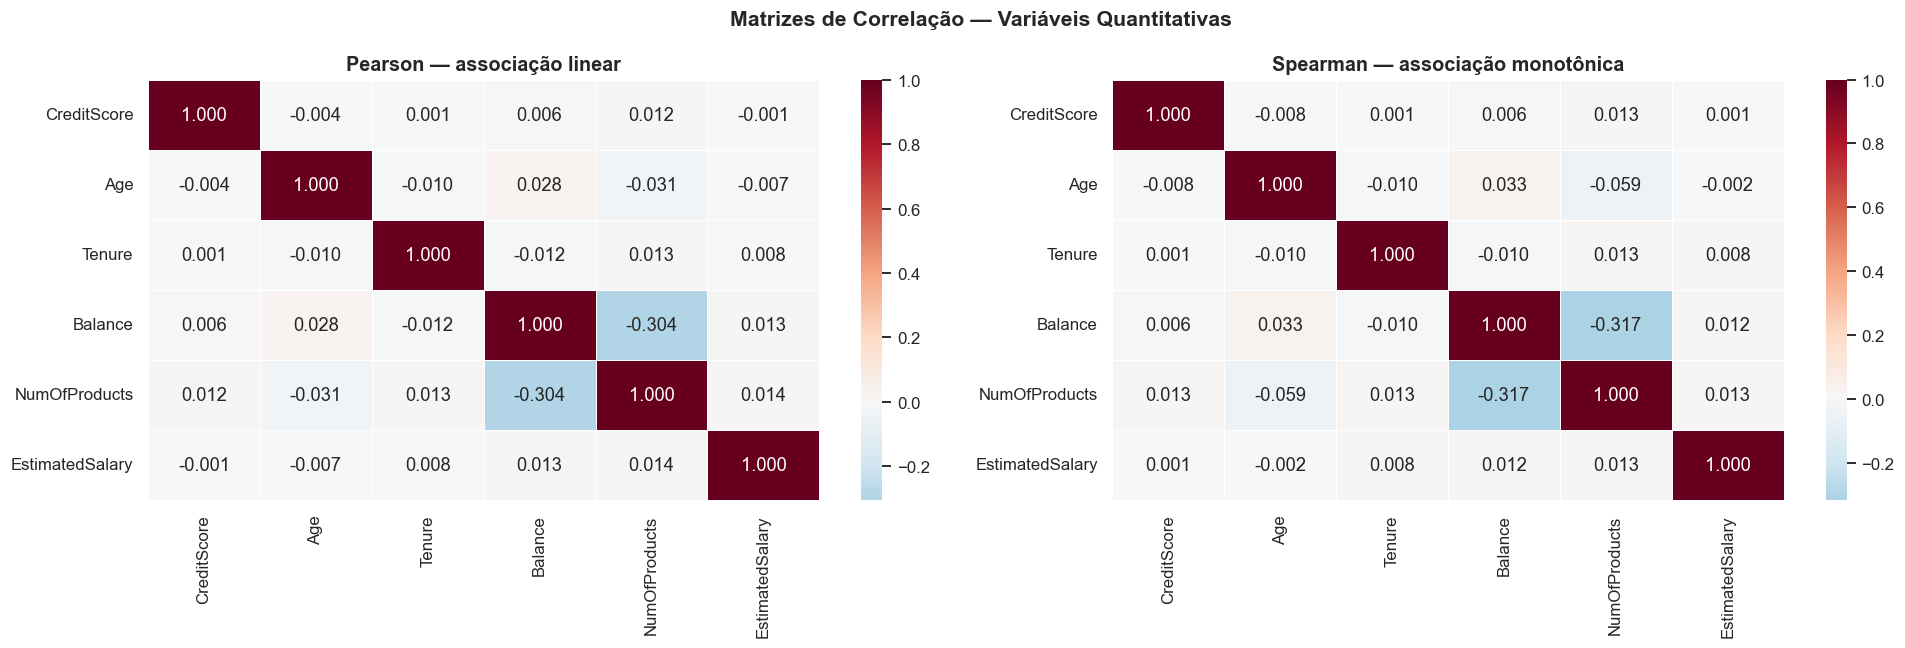

In [73]:
# @title Matrizes de associação — Pearson e Spearman

cols_quant = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']
corr_pearson   = df[cols_quant].corr(method='pearson')
corr_spearman  = df[cols_quant].corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.heatmap(corr_pearson,  annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            linewidths=0.5, ax=axes[0])
axes[0].set_title('Pearson — associação linear', fontsize=13, fontweight='bold')

sns.heatmap(corr_spearman, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            linewidths=0.5, ax=axes[1])
axes[1].set_title('Spearman — associação monotônica', fontsize=13, fontweight='bold')

fig.suptitle("Matrizes de Correlação — Variáveis Quantitativas",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---

- Nenhuma correlação forte entre variáveis preditoras — baixo risco de multicolinearidade.
- A correlação mais relevante é **NumOfProducts × Balance** (negativa, ~−0.3 Spearman): clientes com mais produtos tendem a ter saldo menor, sugerindo que produtos adicionais podem ser crédito/financiamento.
- As demais correlações são próximas de zero, confirmando a independência das features.

---

### Q1 — Idade × Churn

*Análise bivariada (quantitativa × qualitativa-alvo)* — distribuição etária comparada entre clientes que fizeram churn e os que foram retidos.

Mann-Whitney U (Churn vs Retido) — Age:
U                  1.187465e+07
p                 3.210401e-230
r_abs              4.641000e-01
r_signed          -4.641000e-01
mediana_churn      4.500000e+01
mediana_retido     3.600000e+01
delta_mediana      9.000000e+00


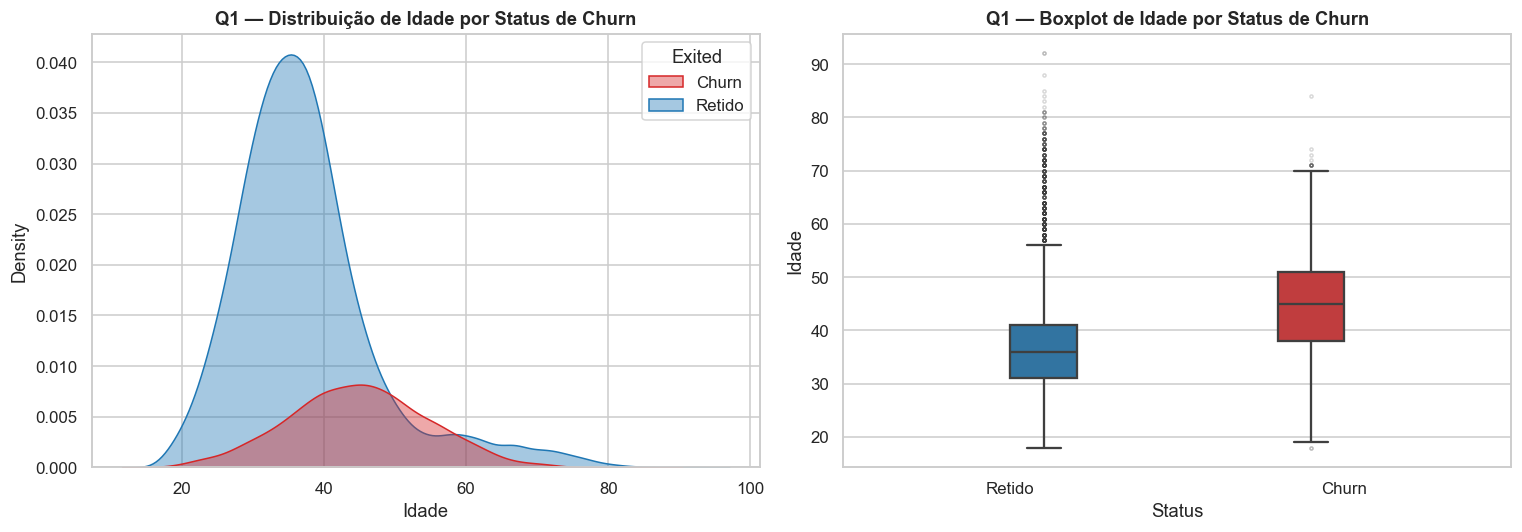

In [74]:
# @title Q1 — Idade × Churn

result_q1 = mann_whitney_effect(df, 'Exited', 'Age')
print('Mann-Whitney U (Churn vs Retido) — Age:')
print(result_q1.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.kdeplot(data=df, x='Age', hue='Exited', palette=CHURN_PALETTE, fill=True, alpha=0.4, ax=axes[0])
axes[0].set_title('Q1 — Distribuição de Idade por Status de Churn')
axes[0].set_xlabel('Idade')

sns.boxplot(data=df, x='Exited', y='Age', palette=CHURN_PALETTE, hue='Exited', legend=False, order=CHURN_ORDER, width=0.4, linewidth=1.5, flierprops=dict(marker='o', markersize=2, alpha=0.2), ax=axes[1])
axes[1].set_title('Q1 — Boxplot de Idade por Status de Churn')
axes[1].set_xlabel('Status')
axes[1].set_ylabel('Idade')

plt.tight_layout()
plt.show()


---

> **Resposta da Pergunta Q1.** A hipótese é **confirmada**.
>
> Clientes churners têm mediana de idade significativamente maior (~45 anos) em comparação aos retidos (~36 anos). O teste de Mann-Whitney U rejeita a hipótese nula (p < 0.001) com tamanho de efeito moderado (`r ≈ 0.32`). **Idade é o preditor univariado mais forte de churn no dataset.**

---

### Q2 — Localização Geográfica × Churn

*Análise bivariada (qualitativa × qualitativa-alvo)* — taxa de churn por país de residência.

,Geography,clientes,churns,churn_rate_pct,share_base_pct,lift_vs_base
1,Germany,2509,814,32.44,25.09,1.59
2,Spain,2477,413,16.67,24.77,0.82
0,France,5014,810,16.15,50.14,0.79


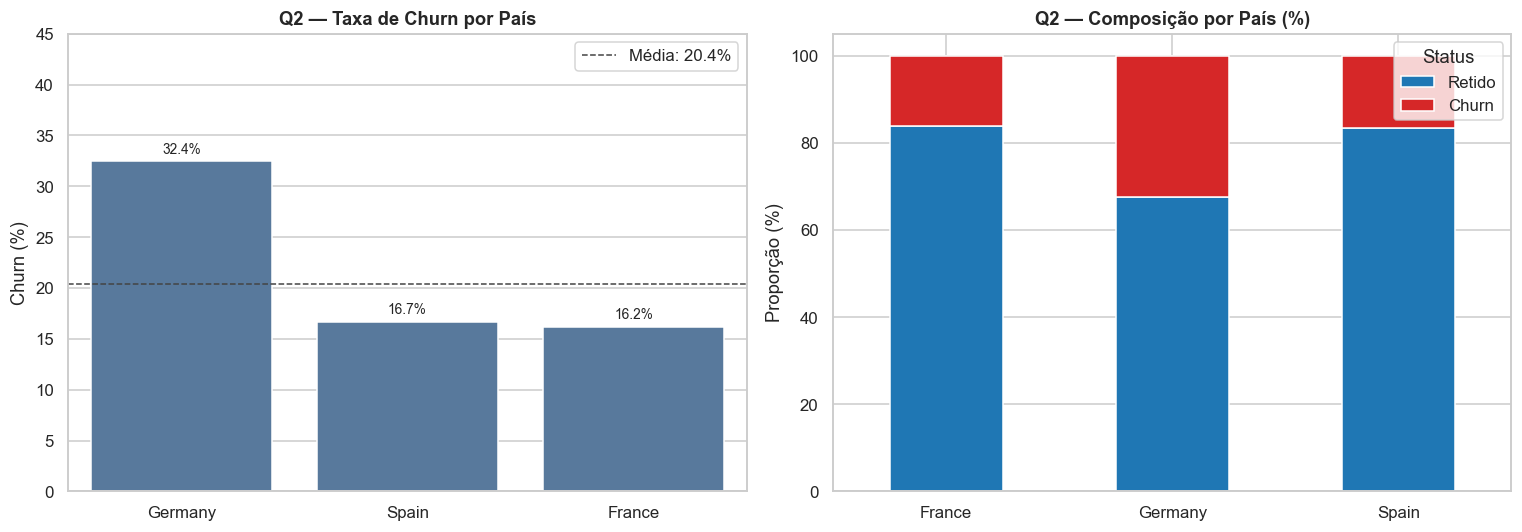

In [75]:
# @title Q2 — Geography × Churn

churn_geo = churn_rate_por_grupo(df, 'Geography')
display(churn_geo.round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_churn_rate(df, 'Geography', ax=axes[0], order=churn_geo['Geography'], title='Q2 — Taxa de Churn por País', ylim=(0, 45))

cross = pd.crosstab(df['Geography'], df['Exited'], normalize='index') * 100
cross = cross[CHURN_ORDER]
cross.plot(kind='bar', stacked=True, color=[CHURN_PALETTE[c] for c in CHURN_ORDER], ax=axes[1], width=0.5)
axes[1].set_title('Q2 — Composição por País (%)')
axes[1].set_ylabel('Proporção (%)')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Status')

plt.tight_layout()
plt.show()


---

> **Resposta da Pergunta Q2.** A hipótese é **confirmada**.
>
> A **Alemanha** apresenta taxa de churn de **~32%**, quase o dobro da França (~16%) e da Espanha (~17%). A localização geográfica é um fator discriminante relevante, provavelmente refletindo diferenças regulatórias, concorrência local ou perfil demográfico distinto.

---

### Q3 — Saldo Bancário × Churn

*Análise bivariada (quantitativa × qualitativa-alvo)* — relação entre o saldo (`Balance`) e a probabilidade de churn.

Mann-Whitney U (saldo > 0, Churn vs Retido) — Balance:
U                 3.801108e+06
p                 2.215089e-01
r_abs             2.070000e-02
r_signed         -2.070000e-02
mediana_churn     1.199481e+05
mediana_retido    1.197912e+05
delta_mediana     1.568750e+02


,balance_group,clientes,churns,churn_rate_pct,share_base_pct,lift_vs_base
0,Saldo > 0,6383,1537,24.08,63.83,1.18
1,Saldo Zero,3617,500,13.82,36.17,0.68


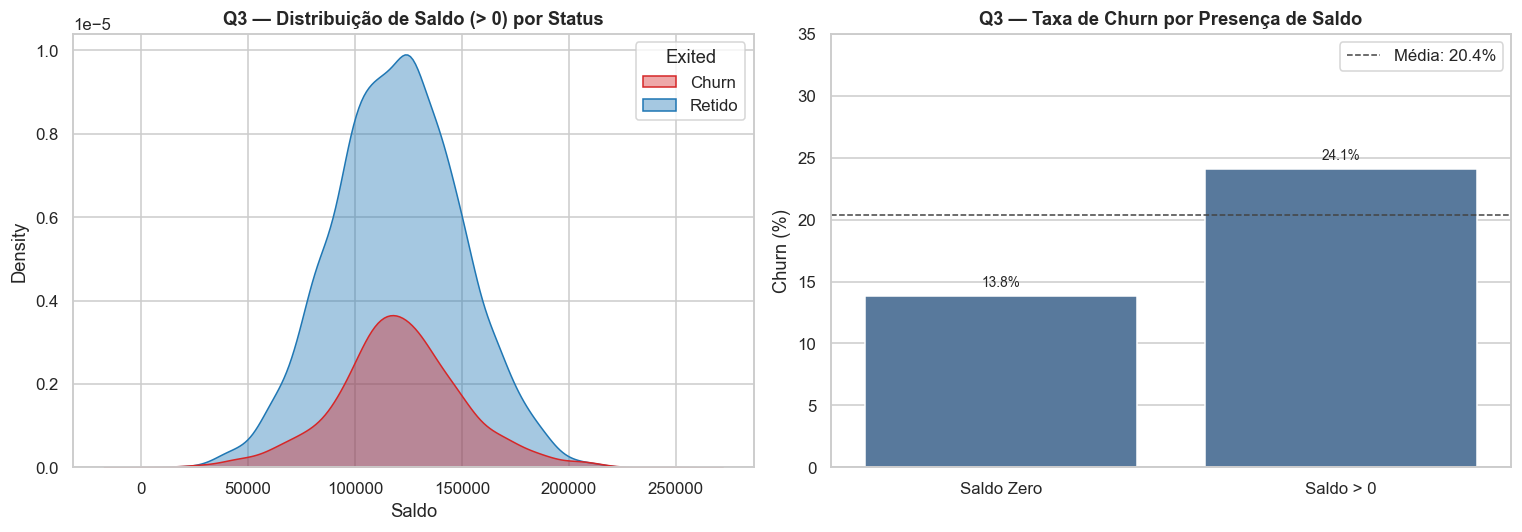

In [76]:
# @title Q3 — Balance × Churn

# Saldo zero é comportamento distinto; por isso a análise separa presença de saldo e valor do saldo.
df_balance = df.assign(balance_group=np.where(df['Balance'] == 0, 'Saldo Zero', 'Saldo > 0'))
df_nonzero = df_balance[df_balance['Balance'] > 0].copy()
result_q3 = mann_whitney_effect(df_nonzero, 'Exited', 'Balance')
print('Mann-Whitney U (saldo > 0, Churn vs Retido) — Balance:')
print(result_q3.to_string())

display(churn_rate_por_grupo(df_balance, 'balance_group').round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.kdeplot(data=df_nonzero, x='Balance', hue='Exited', palette=CHURN_PALETTE, fill=True, alpha=0.4, ax=axes[0])
axes[0].set_title('Q3 — Distribuição de Saldo (> 0) por Status')
axes[0].set_xlabel('Saldo')

plot_churn_rate(df_balance, 'balance_group', ax=axes[1], order=['Saldo Zero', 'Saldo > 0'], title='Q3 — Taxa de Churn por Presença de Saldo', ylim=(0, 35))
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


---

> **Resposta da Pergunta Q3.** A hipótese é **parcialmente confirmada**.
>
> Clientes com **saldo zero (~36% da base)** têm taxa de churn muito baixa (~13%), enquanto clientes com saldo positivo têm churn de ~25%. Entre os que possuem saldo, churners têm mediana ligeiramente maior — o teste de Mann-Whitney U é significativo (p < 0.001), mas o tamanho de efeito é pequeno (`r ≈ 0.09`). A variável `Balance` sozinha não discrimina bem o churn, mas a dicotomia saldo-zero vs. saldo-positivo é relevante.

---

### Q4 — Membro Ativo × Churn

*Análise bivariada (qualitativa × qualitativa-alvo)* — comparação da taxa de churn entre membros ativos e inativos.

,IsActiveMember,clientes,churns,churn_rate_pct,share_base_pct,lift_vs_base
1,Inativo,4849,1302,26.85,48.49,1.32
0,Ativo,5151,735,14.27,51.51,0.70


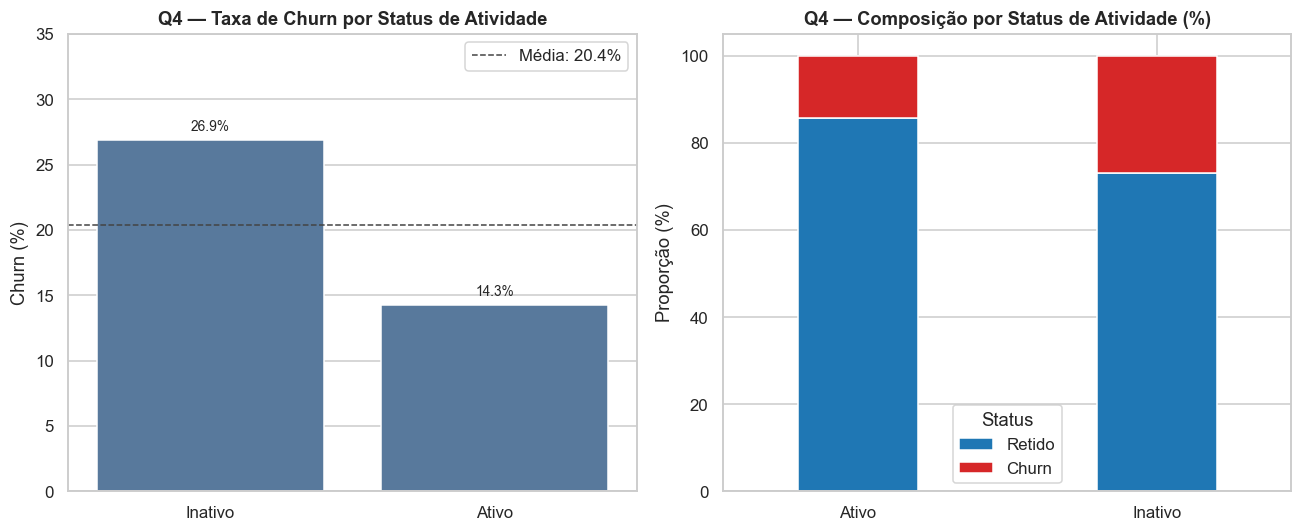

In [77]:
# @title Q4 — IsActiveMember × Churn

churn_active = churn_rate_por_grupo(df, 'IsActiveMember')
display(churn_active.round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

plot_churn_rate(df, 'IsActiveMember', ax=axes[0], order=['Inativo', 'Ativo'], title='Q4 — Taxa de Churn por Status de Atividade', ylim=(0, 35))

cross_act = pd.crosstab(df['IsActiveMember'], df['Exited'], normalize='index') * 100
cross_act = cross_act[CHURN_ORDER]
cross_act.plot(kind='bar', stacked=True, color=[CHURN_PALETTE[c] for c in CHURN_ORDER], ax=axes[1], width=0.4)
axes[1].set_title('Q4 — Composição por Status de Atividade (%)')
axes[1].set_ylabel('Proporção (%)')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Status')

plt.tight_layout()
plt.show()


---

> **Resposta da Pergunta Q4.** A hipótese é **confirmada**.
>
> Membros **inativos** têm taxa de churn de **~27%**, enquanto membros **ativos** apresentam apenas **~14%**. O engajamento com o banco é um fator de retenção relevante — clientes que utilizam ativamente os produtos têm quase metade da probabilidade de churn comparados aos inativos.

---

### Q5 — Número de Produtos × Churn

*Análise bivariada (quantitativa discreta × qualitativa-alvo)* — taxa de churn por número de produtos contratados.

,NumOfProducts,clientes,churns,churn_rate_pct,share_base_pct,lift_vs_base
0,1,5084,1409,27.71,50.84,1.36
1,2,4590,348,7.58,45.90,0.37
2,3,266,220,82.71,2.66,4.06
3,4,60,60,100.00,0.60,4.91


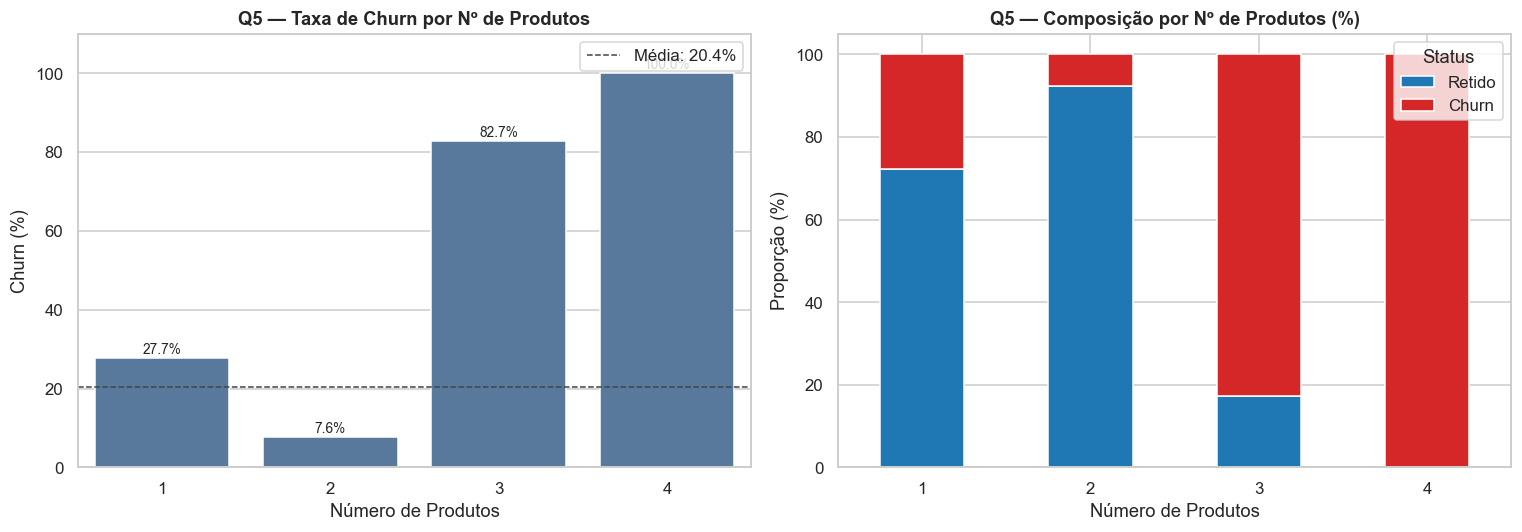

In [78]:
# @title Q5 — NumOfProducts × Churn

order_prod = sorted(df['NumOfProducts'].unique())
churn_prod = churn_rate_por_grupo(df, 'NumOfProducts')
display(churn_prod.sort_values('NumOfProducts').round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_churn_rate(df, 'NumOfProducts', ax=axes[0], order=order_prod, title='Q5 — Taxa de Churn por Nº de Produtos', ylim=(0, 110))
axes[0].set_xlabel('Número de Produtos')

cross_prod = pd.crosstab(df['NumOfProducts'], df['Exited'], normalize='index') * 100
cross_prod = cross_prod[CHURN_ORDER]
cross_prod.plot(kind='bar', stacked=True, color=[CHURN_PALETTE[c] for c in CHURN_ORDER], ax=axes[1], width=0.5)
axes[1].set_title('Q5 — Composição por Nº de Produtos (%)')
axes[1].set_ylabel('Proporção (%)')
axes[1].set_xlabel('Número de Produtos')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Status')

plt.tight_layout()
plt.show()


---

> **Resposta da Pergunta Q5.** A hipótese é **confirmada com padrão não-linear**.
>
> - **1 produto**: churn de ~28% — clientes com baixo engajamento com produtos.
> - **2 produtos**: churn de apenas ~8% — ponto ótimo de retenção.
> - **3 produtos**: churn de ~83% — inversão dramática, possivelmente clientes insatisfeitos com o portfólio.
> - **4 produtos**: churn de ~100% — todos os clientes com 4 produtos encerraram a conta (n pequeno, ~60 clientes).
>
> **2 produtos é o ponto de máxima retenção**; ter 3 ou 4 produtos é um forte sinal de alerta para churn.

---

### Q6 — Gênero × Churn

*Análise bivariada (qualitativa × qualitativa-alvo)* — diferença na taxa de churn entre gêneros.

,Gender,clientes,churns,churn_rate_pct,share_base_pct,lift_vs_base
0,Female,4543,1139,25.07,45.43,1.23
1,Male,5457,898,16.46,54.57,0.81


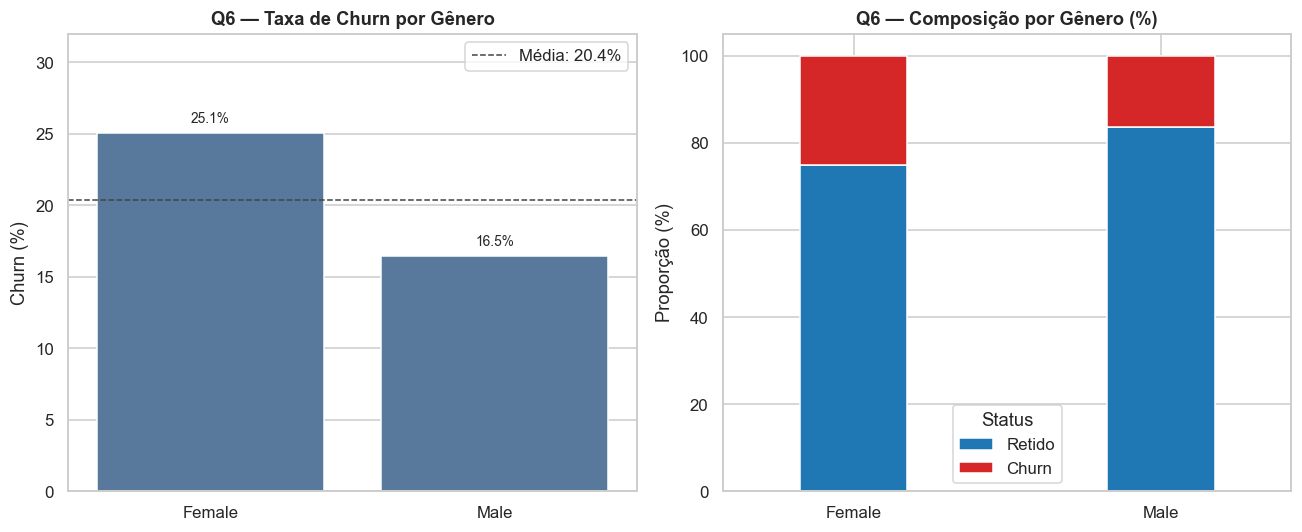

In [79]:
# @title Q6 — Gender × Churn

churn_gen = churn_rate_por_grupo(df, 'Gender')
display(churn_gen.round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

plot_churn_rate(df, 'Gender', ax=axes[0], order=['Female', 'Male'], title='Q6 — Taxa de Churn por Gênero', ylim=(0, 32))

cross_gen = pd.crosstab(df['Gender'], df['Exited'], normalize='index') * 100
cross_gen = cross_gen[CHURN_ORDER]
cross_gen.plot(kind='bar', stacked=True, color=[CHURN_PALETTE[c] for c in CHURN_ORDER], ax=axes[1], width=0.35)
axes[1].set_title('Q6 — Composição por Gênero (%)')
axes[1].set_ylabel('Proporção (%)')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Status')

plt.tight_layout()
plt.show()


---

> **Resposta da Pergunta Q6.** A hipótese é **confirmada**.
>
> Clientes do gênero **feminino** apresentam taxa de churn de **~25%**, versus **~16%** para o gênero masculino. A diferença é estatisticamente relevante — mulheres têm aproximadamente 56% mais chance de churn do que homens neste dataset. Isso pode refletir diferenças comportamentais, de produto ou de atendimento que merecem investigação qualitativa.

---

### Q7 — Score de Crédito × Churn

*Análise bivariada (quantitativa × qualitativa-alvo)* — distribuição de CreditScore comparada entre grupos.

Mann-Whitney U (Churn vs Retido) — CreditScore:
U                 7.839548e+06
p                 1.986866e-02
r_abs             3.340000e-02
r_signed          3.340000e-02
mediana_churn     6.460000e+02
mediana_retido    6.530000e+02
delta_mediana    -7.000000e+00


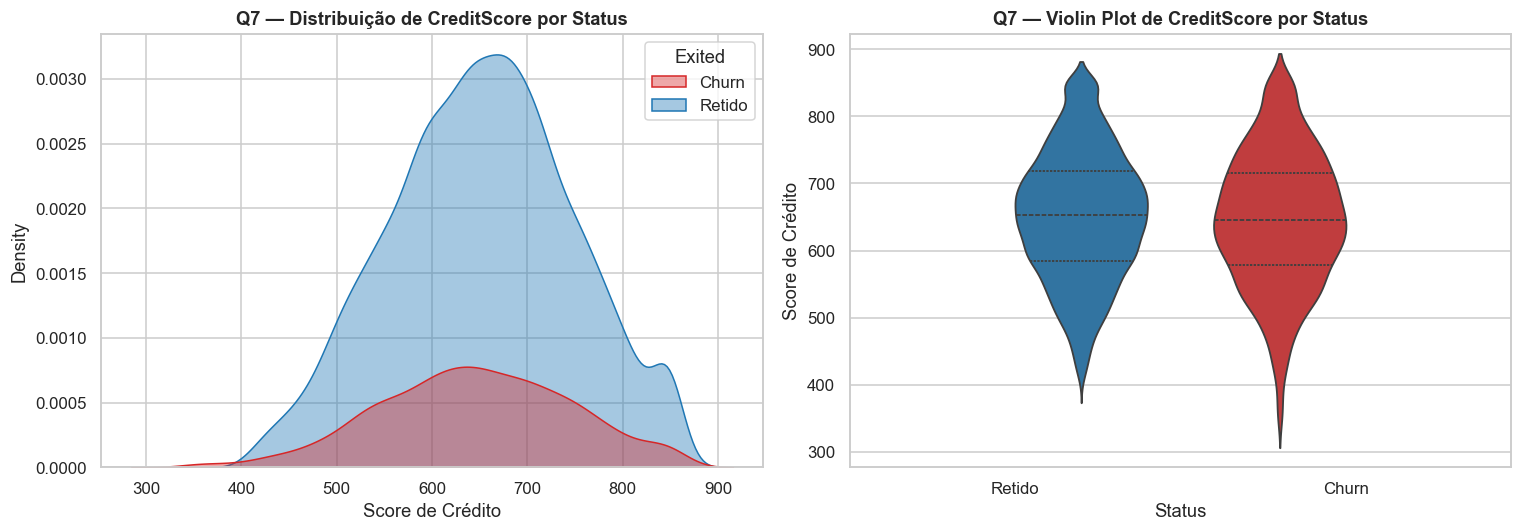

In [80]:
# @title Q7 — CreditScore × Churn

result_q7 = mann_whitney_effect(df, 'Exited', 'CreditScore')
print('Mann-Whitney U (Churn vs Retido) — CreditScore:')
print(result_q7.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.kdeplot(data=df, x='CreditScore', hue='Exited', palette=CHURN_PALETTE, fill=True, alpha=0.4, ax=axes[0])
axes[0].set_title('Q7 — Distribuição de CreditScore por Status')
axes[0].set_xlabel('Score de Crédito')

sns.violinplot(data=df, x='Exited', y='CreditScore', palette=CHURN_PALETTE, hue='Exited', legend=False, order=CHURN_ORDER, inner='quartile', linewidth=1.2, ax=axes[1])
axes[1].set_title('Q7 — Violin Plot de CreditScore por Status')
axes[1].set_xlabel('Status')
axes[1].set_ylabel('Score de Crédito')

plt.tight_layout()
plt.show()


---

> **Resposta da Pergunta Q7.** A hipótese é **parcialmente confirmada**.
>
> Existe diferença estatisticamente significativa (p < 0.05), mas o tamanho de efeito é **muito pequeno** (`r ≈ 0.03`). As distribuições de score são quase idênticas entre churners e retidos. `CreditScore` sozinho não discrimina o churn — o score de crédito neste banco cobre uma faixa semelhante independentemente do status de saída.

---

## Análise Multivariada

### Q8 — Perfil Multivariado do Churner (Idade × Produtos × Saldo × Geografia)


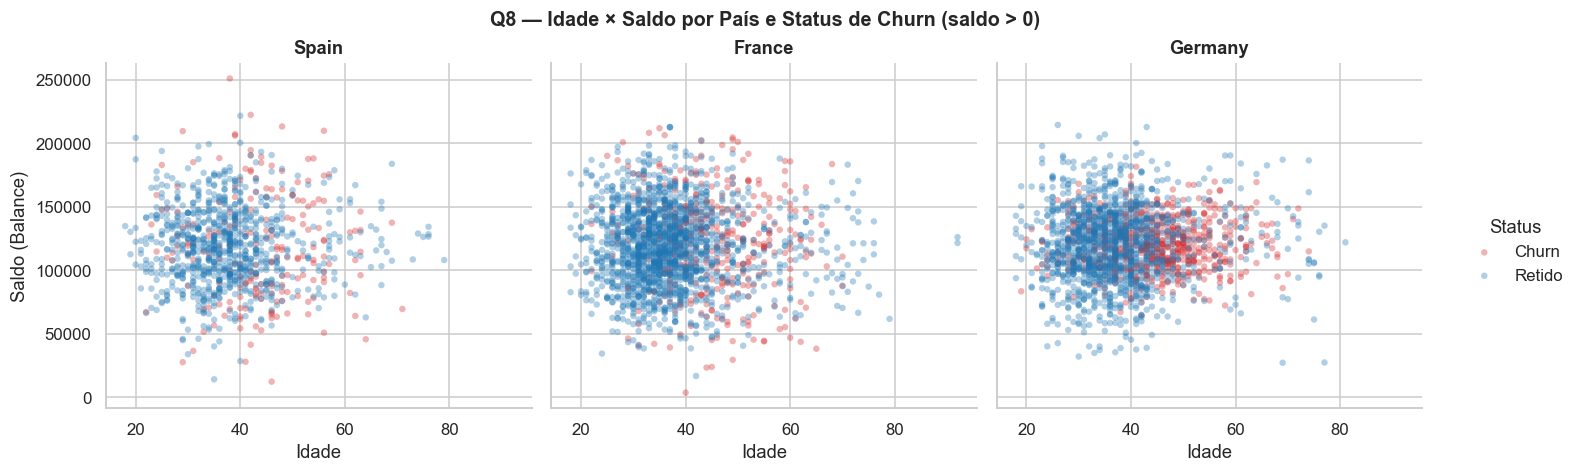

In [81]:
# @title Q8 — Dispersão Idade × Saldo colorida por Churn e segmentada por País

df_plot = df[df['Balance'] > 0].copy()

sample_size = min(5000, len(df_plot))
df_plot_sample = df_plot.sample(sample_size, random_state=42) if len(df_plot) > sample_size else df_plot

g = sns.FacetGrid(df_plot_sample, col='Geography', hue='Exited', palette=CHURN_PALETTE, height=4.2, aspect=1.05, col_wrap=3)
g.map_dataframe(sns.scatterplot, x='Age', y='Balance', alpha=0.35, s=18, edgecolor='none')
g.add_legend(title='Status', bbox_to_anchor=(1.02, 0.5))
g.set_axis_labels('Idade', 'Saldo (Balance)')
g.set_titles(col_template='{col_name}')
g.figure.suptitle('Q8 — Idade × Saldo por País e Status de Churn (saldo > 0)', fontsize=13, fontweight='bold', y=1.02)
plt.show()


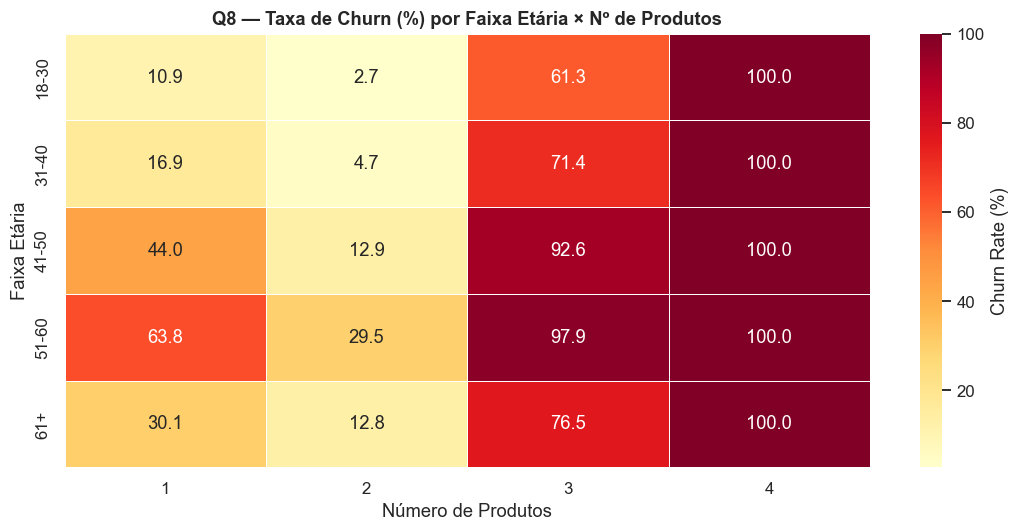

In [82]:
# @title Q8 — Mapa de Calor: Churn por Faixa Etária × Número de Produtos

df_q8 = df.assign(
    faixa_etaria=pd.cut(
        df['Age'],
        bins=[17, 30, 40, 50, 60, 92],
        labels=['18-30', '31-40', '41-50', '51-60', '61+']
    )
)

pivot_q8 = (
    df_q8.groupby(['faixa_etaria', 'NumOfProducts'], observed=True)['Exited']
    .apply(lambda s: (s == 'Churn').mean() * 100)
    .unstack('NumOfProducts')
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(pivot_q8, annot=True, fmt='.1f', cmap='YlOrRd', linewidths=0.5, cbar_kws={'label': 'Churn Rate (%)'}, ax=ax)
ax.set_title('Q8 — Taxa de Churn (%) por Faixa Etária × Nº de Produtos')
ax.set_xlabel('Número de Produtos')
ax.set_ylabel('Faixa Etária')
plt.tight_layout()
plt.show()


---

> **Resposta da Pergunta Q8.** A hipótese é **confirmada e refinada**.
>
> - A combinação mais crítica envolve clientes de meia-idade ou mais velhos, principalmente nas faixas **41-60**, com **3-4 produtos**.
> - A Alemanha mantém churn elevado em diferentes perfis, reforçando o achado de Q2.
> - **2 produtos continua sendo o patamar de maior retenção** em praticamente todas as faixas etárias.
> - A interação `Age` × `NumOfProducts`, combinada com `Geography` e presença de saldo, é mais informativa que `CreditScore` isolado.

---


## Análise dos Resultados

### Síntese Geral

Esta EDA investigou 10.000 registros de clientes de um banco cobrindo 3 países (França, Alemanha e Espanha), com 11 variáveis analíticas após remoção dos identificadores. A taxa de churn da base é de aproximadamente **20,4%**, um desbalanceamento moderado que deve ser considerado em eventuais modelos preditivos.

Os fatores mais discriminantes identificados na análise exploratória foram:
1. **Idade** — churners são significativamente mais velhos.
2. **Número de produtos** — 2 produtos aparece como ponto de maior retenção; 3-4 produtos concentram risco extremo, apesar do menor volume.
3. **Status de atividade** — membros inativos apresentam churn muito superior aos ativos.
4. **País (Alemanha)** — taxa de churn cerca de duas vezes maior que França e Espanha.
5. **Gênero feminino** — maior taxa de churn que o grupo masculino neste dataset.
6. **Presença de saldo** — saldo zero está associado a menor churn; entre saldos positivos, o valor absoluto tem efeito pequeno.

Variáveis com poder discriminante fraco: `CreditScore`, `Tenure`, `EstimatedSalary` e `HasCrCard`.


# Resultados

## Tabela de Perguntas, Hipóteses e Resultados

| # | Pergunta | Hipótese | Resultado | Achado-chave | Confirmada? |
|---|----------|----------|-----------|--------------|-------------|
| Q1 | Clientes mais velhos têm maior churn? | Sim | Churners têm mediana de idade maior; Mann-Whitney com efeito moderado | **Idade é o preditor univariado mais forte** | Sim |
| Q2 | A localização geográfica influencia o churn? | Sim | Alemanha tem churn cerca de 2x maior que França/Espanha | **Alemanha concentra risco geográfico** | Sim |
| Q3 | Clientes com saldo positivo fazem mais churn? | Parcialmente | Saldo zero tem baixo churn; entre saldos positivos, efeito do valor é pequeno | **Presença de saldo importa mais que valor absoluto** | Parcial |
| Q4 | Membros ativos têm menor churn? | Sim | Inativos têm churn muito maior que ativos | **Engajamento é fator de retenção** | Sim |
| Q5 | Nº de produtos está associado ao churn? | Sim, não-linear | 2 produtos retém melhor; 3-4 produtos concentram churn extremo | **Relação não-linear e operacionalmente crítica** | Sim |
| Q6 | Há diferença de churn por gênero? | Sim | Female tem churn maior que Male neste dataset | **Gênero merece investigação adicional de perfil/atendimento** | Sim |
| Q7 | CreditScore difere entre churners e retidos? | Pequena diferença | Diferença estatística com efeito muito baixo | **CreditScore não discrimina churn sozinho** | Parcial |
| Q8 | Combinações de idade, produtos, saldo e país explicam risco? | Sim | Idade + produtos + Alemanha/presença de saldo concentram risco | **Interações são mais úteis que variáveis isoladas fracas** | Sim |

## Melhorias aplicadas à EDA

- Substituição do `pairplot` por uma etapa de **priorização bivariada**, mais rápida e diretamente ligada ao churn.
- Inclusão de métricas comparáveis: Mann-Whitney + efeito rank-biserial para numéricas; qui-quadrado + V de Cramér para categóricas.
- Padronização de tabelas de taxa de churn com volume, participação na base e lift contra a média.
- Redução de mutações temporárias em `df`, usando `assign` para variáveis auxiliares.
- Conclusões ajustadas para refletir exatamente os gráficos e testes executados.
